In [61]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# analysis/ notebook -> results live one level up
RESULTS_ROOT = "../.."
SWEEP_DIRS = {
    "image": os.path.join(RESULTS_ROOT, "results", "lr_sweep_results_image_5seeds"),
    "text":  os.path.join(RESULTS_ROOT, "results", "lr_sweep_results_text_5seeds"),
}

In [62]:
def collect_runs(sweep_dir):
    """Find all run_summary.csv under sweep_dir and return a tidy DataFrame."""
    rows = []
    pattern = os.path.join(sweep_dir, "**", "run_summary.csv")
    for path in glob.glob(pattern, recursive=True):
        df = pd.read_csv(path)
        r = df.iloc[0].to_dict()
        rows.append({
            "lr": float(r["lr"]),
            "seed": int(r["seed"]),
            "final_overall": float(r["final_overall"]),
            "path": path,
        })
    if not rows:
        print(f"WARNING: no run_summary.csv found under {sweep_dir}")
    return pd.DataFrame(rows)

runs = {}
for cond, d in SWEEP_DIRS.items():
    runs[cond] = collect_runs(d)
    print(f"{cond}: {len(runs[cond])} runs, "
          f"{runs[cond]['lr'].nunique() if len(runs[cond]) else 0} LRs")

runs["image"].head()

image: 50 runs, 10 LRs
text: 50 runs, 10 LRs


,lr,seed,final_overall,path
0,0.001,24512,0.760504,../../results/lr_sweep_results_image_5seeds/lr...
1,0.001,34063,0.693277,../../results/lr_sweep_results_image_5seeds/lr...
2,0.001,59920,0.924370,../../results/lr_sweep_results_image_5seeds/lr...
3,0.001,40832,0.882353,../../results/lr_sweep_results_image_5seeds/lr...
4,0.001,40335,0.840336,../../results/lr_sweep_results_image_5seeds/lr...


In [63]:
def aggregate(df):
    g = df.groupby("lr")["final_overall"]
    out = g.agg(["mean", "std", "count"]).reset_index().sort_values("lr")
    out["std"] = out["std"].fillna(0.0)   # std is NaN when only 1 run
    return out

agg = {cond: aggregate(df) for cond, df in runs.items() if len(df)}
for cond, a in agg.items():
    print(f"\n=== {cond} ===")
    print(a.to_string(index=False))


=== image ===
    lr     mean      std  count
0.0009 0.818487 0.018884      5
0.0010 0.820168 0.093264      5
0.0030 0.768067 0.088105      5
0.0050 0.721008 0.070596      5
0.0075 0.676471 0.048729      5
0.0100 0.676471 0.067685      5
0.0300 0.536975 0.023657      5
0.0500 0.500000 0.000000      5
0.0750 0.500000 0.000000      5
0.1000 0.500000 0.000000      5

=== text ===
    lr     mean      std  count
0.0009 0.933613 0.025105      5
0.0010 0.941176 0.020797      5
0.0030 0.920168 0.021629      5
0.0050 0.849580 0.058778      5
0.0075 0.781513 0.058899      5
0.0100 0.735294 0.045253      5
0.0300 0.662185 0.021752      5
0.0500 0.652941 0.009673      5
0.0750 0.652101 0.005478      5
0.1000 0.659664 0.017826      5


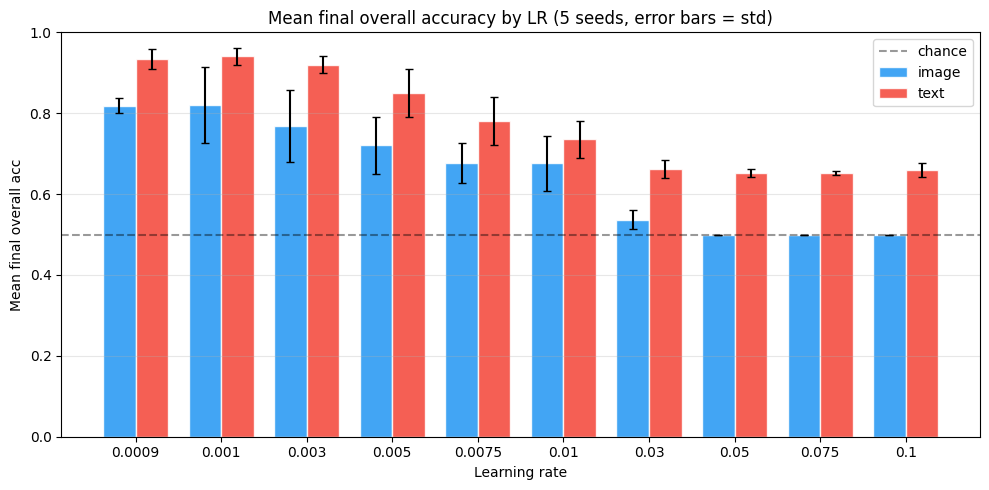

In [64]:
# Union of LRs across both conditions, sorted
all_lrs = sorted(set().union(*[set(a["lr"]) for a in agg.values()]))
x = np.arange(len(all_lrs))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
colors = {"image": "#2196F3", "text": "#F44336"}

for i, (cond, a) in enumerate(agg.items()):
    a_idx = a.set_index("lr")
    means = [a_idx["mean"].get(lr, np.nan) for lr in all_lrs]
    errs  = [a_idx["std"].get(lr, np.nan)  for lr in all_lrs]
    ax.bar(x + (i - (len(agg) - 1) / 2) * width, means, width,
           yerr=errs, capsize=3, label=cond, color=colors.get(cond),
           alpha=0.85, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([f"{lr:g}" for lr in all_lrs])
ax.set_xlabel("Learning rate")
ax.set_ylabel("Mean final overall acc")
ax.set_ylim(0, 1)
ax.axhline(0.5, color="k", ls="--", alpha=0.4, label="chance")
ax.set_title("Mean final overall accuracy by LR (5 seeds, error bars = std)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()